# Hyperparameter Search Notebook

In [1]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline as ModelPipeline
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', font_scale=0.9)
pd.set_option('display.max_columns', 80)

RANDOM_STATE = 42
PHASE1_RERUN = False
PHASE2_RERUN = False
FIGURE_DPI = 160
CPU_COUNT = os.cpu_count() or 1
SEARCH_N_JOBS = max(1, min(8, CPU_COUNT))
MODEL_FIT_N_JOBS = 1
SEARCH_PRE_DISPATCH = SEARCH_N_JOBS
SEARCH_VERBOSE = 2

project_root = Path.cwd().resolve()
if not (project_root / 'src').exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.pipeline import build_pipeline, load_feature_frame, random_split

results_dir = project_root / 'results'
results_dir.mkdir(parents=True, exist_ok=True)
data_path = project_root / 'data' / 'processed' / 'matches.parquet'
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
phase1_models = ('LR', 'RF', 'XGB')

Matplotlib is building the font cache; this may take a moment.


In [2]:
df_feat, y, df_meta = load_feature_frame(data_path, feature_set='clean')
splits = random_split(len(df_feat), y, test_size=0.20, val_size=0.125, seed=RANDOM_STATE)

X_train_raw = df_feat.iloc[splits['train']].copy()
X_val_raw = df_feat.iloc[splits['val']].copy()
X_test_raw = df_feat.iloc[splits['test']].copy()
y_train = y.iloc[splits['train']].copy()
y_val = y.iloc[splits['val']].copy()
y_test = y.iloc[splits['test']].copy()

## Phase 1 Search

Run Phase 1 on the raw training fold only. Each model starts from a reasonable anchor configuration, then sweeps one hyperparameter at a time while holding the others fixed. Use broader initial grids and finer follow-up grids across multiple Phase 1 rounds until each parameter range is stable enough for Phase 2 joint search. Preprocessing is nested inside each search estimator so every CV split fits its own transformer state. Validation and test splits remain untouched during model selection.

In [3]:
phase1_csv_paths = {
    'LR': results_dir / 'hpsearch_lr_p1.csv',
    'RF': results_dir / 'hpsearch_rf_p1_round3.csv',
    'XGB': results_dir / 'hpsearch_xgb_p1_round4.csv',
}

lr_p1_anchor = {'C': 1.0}
lr_p1_sweeps = {
    'C': [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
}

# Round 3 anchor: n_estimators=500 (cost-capped), max_features=0.04 (round 3 best, lower boundary confirmed).
rf_p1_anchor = {
    'n_estimators': 500,
    'max_depth': 28,
    'min_samples_leaf': 4,
    'max_features': 0.04,
}
rf_p1_confirmed_space = {
    # Round 2 did not add evidence to reopen depth; keep the compact carry-over space from the earlier scan.
    'max_depth': [16, 20, 28, None],
    # Round 2 still supports the smoother leaf sizes; keep the anti-overfitting compact space.
    'min_samples_leaf': [4, 6, 8, 12],
    # Monotonically improving across all rounds; locked to a cost-practical range for Phase 2.
    'n_estimators': [300, 500, 700],
    # Round 3 best at 0.04 (lower boundary); Phase 2 will fine-scan around this value.
    'max_features': [0.04],
}
rf_p1_sweeps = {
    # Round 2 best at 0.08 on the lower edge; rescan further downward and keep sqrt as a coarse reference.
    'max_features': [0.04, 0.06, 0.08, 0.1, 0.12, 'sqrt'],
}

# Round 4 anchor moves to the current best round-3 settings and keeps only the two unresolved dimensions active.
xgb_p1_anchor = {
    'learning_rate': 0.07,
    'max_depth': 5,
    'n_estimators': 400,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
}
xgb_p1_confirmed_space = {
    # Depth stayed in a stable shallow region across rounds 2 and 3; carry this compact band forward.
    'max_depth': [4, 5, 6],
    # Row subsampling remained centered near 0.8 with only tiny differences around it.
    'subsample': [0.7, 0.8, 0.9],
    # Column subsampling stayed stable around 0.7 after refinement.
    'colsample_bytree': [0.6, 0.7, 0.8],
}
xgb_p1_sweeps = {
    # Round 3 best at 0.07 on the lower boundary; shift downward but keep one upper reference point.
    'learning_rate': [0.04, 0.05, 0.07, 0.09],
    # Round 3 best at 400 on the lower boundary; rescan a lower tree-count band while retaining 500 as a reference.
    'n_estimators': [250, 300, 400, 500],
}

phase1_anchor_params = {
    'LR': lr_p1_anchor,
    'RF': rf_p1_anchor,
    'XGB': xgb_p1_anchor,
}
phase1_sweep_spaces = {
    'LR': lr_p1_sweeps,
    'RF': rf_p1_sweeps,
    'XGB': xgb_p1_sweeps,
}

def build_model_pipeline(estimator):
    return ModelPipeline([
        ('preprocess', build_pipeline()),
        ('model', estimator),
    ])


def prefix_model_params(param_space):
    return {f'model__{name}': values for name, values in param_space.items()}


def normalize_cv_results(results_df):
    rename_map = {
        column: column.replace('param_model__', 'param_')
        for column in results_df.columns
        if column.startswith('param_model__')
    }
    normalized = results_df.rename(columns=rename_map).copy()
    if 'params' in normalized.columns:
        normalized['params'] = normalized['params'].map(
            lambda params: {key.replace('model__', ''): value for key, value in params.items()}
            if isinstance(params, dict)
            else params
        )
    return normalized


def estimate_sweep_trial_count(sweep_space):
    return sum(len(candidates) for candidates in sweep_space.values())


def build_single_param_grid(anchor_params, param_name, candidates):
    grid = {f'model__{name}': [value] for name, value in anchor_params.items()}
    grid[f'model__{param_name}'] = list(candidates)
    return grid


def filter_sweep_results(results_df, param_name):
    working = results_df.copy()
    if 'sweep_param' in working.columns:
        working = working[working['sweep_param'] == param_name].copy()
    return working


def run_or_load_phase1_sweeps(model_name, estimator, anchor_params, sweep_space, X_raw, y_target, csv_path, rerun=False):
    if csv_path.exists() and not rerun:
        print(f'Loading cached Phase 1 results for {model_name} from {csv_path.name}')
        return pd.read_csv(csv_path)

    total_trials = estimate_sweep_trial_count(sweep_space)
    print(f'=== {model_name} Phase 1 ===')
    print(f'anchor_params={anchor_params}')
    print(f'output_csv={csv_path.name}')
    print(f'total_candidates={total_trials}, total_fits={total_trials * cv.get_n_splits()}')

    sweep_frames = []
    total_elapsed = 0.0
    for param_name, candidates in sweep_space.items():
        print(f'Scanning {param_name}: {list(candidates)}')
        search = GridSearchCV(
            build_model_pipeline(clone(estimator)),
            param_grid=build_single_param_grid(anchor_params, param_name, candidates),
            cv=cv,
            scoring='roc_auc',
            n_jobs=SEARCH_N_JOBS,
            pre_dispatch=SEARCH_PRE_DISPATCH,
            return_train_score=True,
            verbose=SEARCH_VERBOSE,
        )
        start = time.perf_counter()
        search.fit(X_raw, y_target)
        elapsed = time.perf_counter() - start
        total_elapsed += elapsed

        sweep_df = normalize_cv_results(pd.DataFrame(search.cv_results_))
        sweep_df['model'] = model_name
        sweep_df['sweep_param'] = param_name
        sweep_df['anchor_params'] = str(anchor_params)
        sweep_frames.append(sweep_df)

        best_row = best_trial(sweep_df)
        print(
            f'Best {param_name}: value={best_row[f"param_{param_name}"]}, '
            f'cv_auc={best_row["mean_test_score"]:.6f}, elapsed={elapsed:.1f}s'
        )

    results_df = pd.concat(sweep_frames, ignore_index=True)
    results_df = results_df.sort_values(['sweep_param', 'rank_test_score', 'mean_fit_time']).reset_index(drop=True)
    results_df.to_csv(csv_path, index=False)
    print(f'Saved {len(results_df)} trials to {csv_path.name} in {total_elapsed:.1f}s')
    return results_df


def best_trial(results_df):
    best_idx = results_df['mean_test_score'].idxmax()
    return results_df.loc[best_idx].copy()


def best_trial_per_sweep(results_df):
    sweep_best_rows = [best_trial(sweep_df) for _, sweep_df in results_df.groupby('sweep_param', sort=False)]
    return pd.DataFrame(sweep_best_rows).reset_index(drop=True)

In [4]:
lr_p1_results = run_or_load_phase1_sweeps(
    'LR',
    LogisticRegression(solver='lbfgs', max_iter=1000),
    phase1_anchor_params['LR'],
    phase1_sweep_spaces['LR'],
    X_train_raw,
    y_train,
    phase1_csv_paths['LR'],
    rerun=PHASE1_RERUN,
)

lr_p1_view = lr_p1_results[
    ['sweep_param', 'param_C', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score', 'rank_test_score']
] .copy()
lr_p1_view['param_C'] = pd.to_numeric(lr_p1_view['param_C'])
display(lr_p1_view.sort_values(['sweep_param', 'param_C']))
display(best_trial(lr_p1_results).to_frame().T[['sweep_param', 'param_C', 'mean_test_score', 'std_test_score', 'mean_train_score']])

Loading cached Phase 1 results for LR from hpsearch_lr_p1.csv


,sweep_param,param_C,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score
10,C,0.001,0.737891,0.005258,0.740464,0.001130,11
9,C,0.003,0.745431,0.004900,0.748280,0.001079,10
8,C,0.010,0.748106,0.004540,0.751084,0.001069,9
1,C,0.030,0.748404,0.004391,0.751428,0.001069,2
0,C,0.100,0.748406,0.004346,0.751424,0.001075,1
2,C,0.300,0.748390,0.004326,0.751405,0.001071,3
3,C,1.000,0.748384,0.004318,0.751398,0.001074,4
4,C,3.000,0.748376,0.004330,0.751395,0.001074,5
5,C,10.000,0.748374,0.004326,0.751396,0.001075,6
7,C,30.000,0.748369,0.004324,0.751394,0.001076,8


,sweep_param,param_C,mean_test_score,std_test_score,mean_train_score
0,C,0.1,0.748406,0.004346,0.751424


In [5]:
rf_p1_results = run_or_load_phase1_sweeps(
    'RF',
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=MODEL_FIT_N_JOBS),
    phase1_anchor_params['RF'],
    phase1_sweep_spaces['RF'],
    X_train_raw,
    y_train,
    phase1_csv_paths['RF'],
    rerun=PHASE1_RERUN,
)

rf_p1_view = rf_p1_results[
    [
        'sweep_param',
        'param_n_estimators',
        'param_max_depth',
        'param_min_samples_leaf',
        'param_max_features',
        'mean_test_score',
        'std_test_score',
        'mean_train_score',
        'rank_test_score',
    ]
] .copy()
display(rf_p1_view.sort_values(['sweep_param', 'rank_test_score', 'mean_test_score'], ascending=[True, True, False]))
display(best_trial_per_sweep(rf_p1_results)[
    ['sweep_param', 'param_n_estimators', 'param_max_depth', 'param_min_samples_leaf', 'param_max_features', 'mean_test_score', 'std_test_score', 'mean_train_score']
])

Loading cached Phase 1 results for RF from hpsearch_rf_p1_round3.csv


,sweep_param,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,mean_test_score,std_test_score,mean_train_score,rank_test_score
0,max_features,500,28,4,0.04,0.728822,0.005168,0.999999,1
1,max_features,500,28,4,0.06,0.728429,0.005246,1.000000,2
2,max_features,500,28,4,0.08,0.727869,0.004943,0.999999,3
3,max_features,500,28,4,sqrt,0.727751,0.004979,0.999999,4
4,max_features,500,28,4,0.1,0.726719,0.004834,0.999999,5
5,max_features,500,28,4,0.12,0.726522,0.005657,0.999999,6


,sweep_param,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,mean_test_score,std_test_score,mean_train_score
0,max_features,500,28,4,0.04,0.728822,0.005168,0.999999


In [6]:
xgb_p1_results = run_or_load_phase1_sweeps(
    'XGB',
    XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=MODEL_FIT_N_JOBS,
        verbosity=0,
        eval_metric='logloss',
    ),
    phase1_anchor_params['XGB'],
    phase1_sweep_spaces['XGB'],
    X_train_raw,
    y_train,
    phase1_csv_paths['XGB'],
    rerun=PHASE1_RERUN,
)

xgb_p1_view = xgb_p1_results[
    [
        'sweep_param',
        'param_learning_rate',
        'param_max_depth',
        'param_n_estimators',
        'param_subsample',
        'param_colsample_bytree',
        'mean_test_score',
        'std_test_score',
        'mean_train_score',
        'rank_test_score',
    ]
] .copy()
display(xgb_p1_view.sort_values(['sweep_param', 'rank_test_score', 'mean_test_score'], ascending=[True, True, False]))
display(best_trial_per_sweep(xgb_p1_results)[
    ['sweep_param', 'param_learning_rate', 'param_max_depth', 'param_n_estimators', 'param_subsample', 'param_colsample_bytree', 'mean_test_score', 'std_test_score', 'mean_train_score']
])

Loading cached Phase 1 results for XGB from hpsearch_xgb_p1_round4.csv


,sweep_param,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,param_colsample_bytree,mean_test_score,std_test_score,mean_train_score,rank_test_score
0,learning_rate,0.07,5,400,0.8,0.7,0.746801,0.006143,0.871923,1
1,learning_rate,0.05,5,400,0.8,0.7,0.746592,0.006127,0.846578,2
2,learning_rate,0.09,5,400,0.8,0.7,0.745105,0.004579,0.892164,3
3,learning_rate,0.04,5,400,0.8,0.7,0.744988,0.005683,0.831120,4
4,n_estimators,0.07,5,500,0.8,0.7,0.747199,0.006136,0.891406,1
5,n_estimators,0.07,5,400,0.8,0.7,0.746801,0.006143,0.871923,2
6,n_estimators,0.07,5,300,0.8,0.7,0.745696,0.006375,0.848788,3
7,n_estimators,0.07,5,250,0.8,0.7,0.744648,0.006154,0.835312,4


,sweep_param,param_learning_rate,param_max_depth,param_n_estimators,param_subsample,param_colsample_bytree,mean_test_score,std_test_score,mean_train_score
0,learning_rate,0.07,5,400,0.8,0.7,0.746801,0.006143,0.871923
1,n_estimators,0.07,5,500,0.8,0.7,0.747199,0.006136,0.891406


## Phase 1 Visualizations

These figures summarize one-dimensional sweep results only. Use them to decide whether each parameter should be expanded, narrowed, or rescanned with a finer grid in the next Phase 1 round before defining the Phase 2 joint search space.

In [32]:
phase1_plot_paths = {
    'lr_curve': results_dir / 'hpsearch_lr_curve_p1.png',
    'rf_sensitivity': results_dir / 'hpsearch_rf_sensitivity_p1.png',
    'xgb_sensitivity': results_dir / 'hpsearch_xgb_sensitivity_p1.png',
}


def normalize_param_value(value):
    if pd.isna(value):
        return None
    if isinstance(value, str):
        stripped = value.strip()
        if stripped.lower() == 'none':
            return None
        try:
            numeric = float(stripped)
            return int(numeric) if numeric.is_integer() else numeric
        except ValueError:
            return stripped
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return int(value) if float(value).is_integer() else float(value)
    return value


def normalize_param_series(series):
    return series.map(normalize_param_value)


def format_param_value(value):
    value = normalize_param_value(value)
    if value is None:
        return 'None'
    return str(value)


def ordered_param_summary(results_df, param_col, order):
    working = results_df.copy()
    if param_col.startswith('param_') and 'sweep_param' in working.columns:
        target_param = param_col.replace('param_', '')
        working = working[working['sweep_param'] == target_param].copy()
    working['_param'] = normalize_param_series(working[param_col])
    normalized_order = [normalize_param_value(value) for value in order]
    summary = (
        working.groupby('_param', dropna=False)['mean_test_score']
        .agg(['mean', 'std'])
        .reindex(normalized_order)
        .reset_index()
        .rename(columns={'_param': 'param_value'})
    )
    summary['label'] = summary['param_value'].map(format_param_value)
    return summary


def save_lr_curve(results_df, out_path, title):
    plot_df = filter_sweep_results(results_df, 'C')[
        ['param_C', 'mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score']
    ].copy()
    plot_df['param_C'] = pd.to_numeric(plot_df['param_C'])
    plot_df = plot_df.sort_values('param_C')

    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.errorbar(
        np.log10(plot_df['param_C']),
        plot_df['mean_test_score'],
        yerr=plot_df['std_test_score'],
        marker='o',
        label='CV AUC',
    )
    ax.errorbar(
        np.log10(plot_df['param_C']),
        plot_df['mean_train_score'],
        yerr=plot_df['std_train_score'],
        marker='s',
        alpha=0.5,
        label='Train AUC',
    )
    ax.set_xlabel(r'$\log_{10} C$')
    ax.set_ylabel('ROC-AUC')
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=FIGURE_DPI, bbox_inches='tight')
    plt.close(fig)


def save_sensitivity_grid(results_df, param_specs, out_path, title, figsize):
    fig, axes = plt.subplots(1, len(param_specs), figsize=figsize, sharey=True)
    if len(param_specs) == 1:
        axes = [axes]

    for ax, (param_name, axis_label, order) in zip(axes, param_specs):
        summary = ordered_param_summary(results_df, f'param_{param_name}', order)
        x_pos = np.arange(len(summary))
        ax.errorbar(
            x_pos,
            summary['mean'],
            yerr=summary['std'].fillna(0),
            marker='o',
        )
        ax.set_xticks(x_pos)
        ax.set_xticklabels(
            summary['label'],
            rotation=30 if len(summary) > 3 else 0,
            ha='right',
        )
        ax.set_xlabel(axis_label)
        ax.set_title(axis_label)
        ax.grid(True, axis='y', alpha=0.3)

    axes[0].set_ylabel('CV ROC-AUC')
    fig.suptitle(title, y=1.04)
    fig.tight_layout()
    fig.savefig(out_path, dpi=FIGURE_DPI, bbox_inches='tight')
    plt.close(fig)

,artifact,path,exists
0,lr_curve,results/hpsearch_lr_curve_p1.png,True
1,rf_sensitivity,results/hpsearch_rf_sensitivity_p1.png,True
2,xgb_sensitivity,results/hpsearch_xgb_sensitivity_p1.png,True


lr_curve: results/hpsearch_lr_curve_p1.png


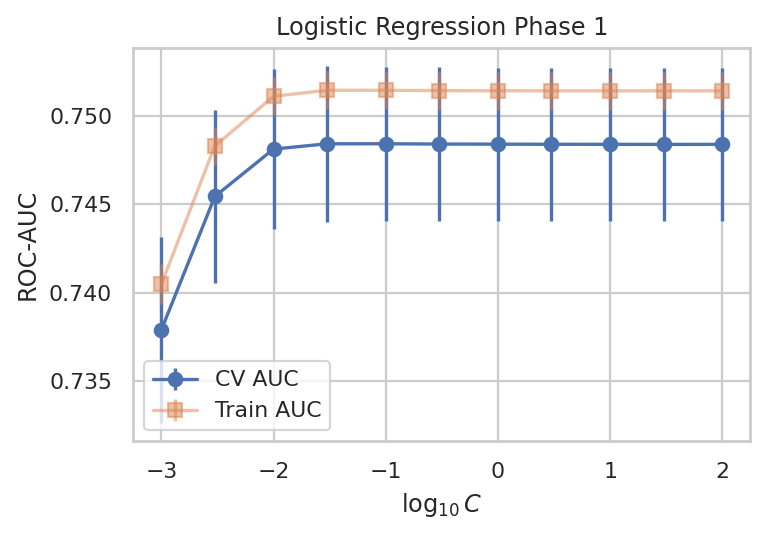

rf_sensitivity: results/hpsearch_rf_sensitivity_p1.png


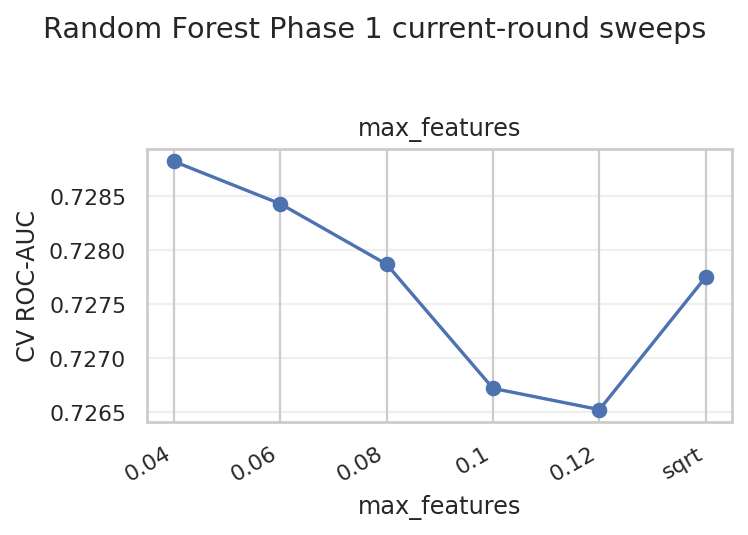

xgb_sensitivity: results/hpsearch_xgb_sensitivity_p1.png


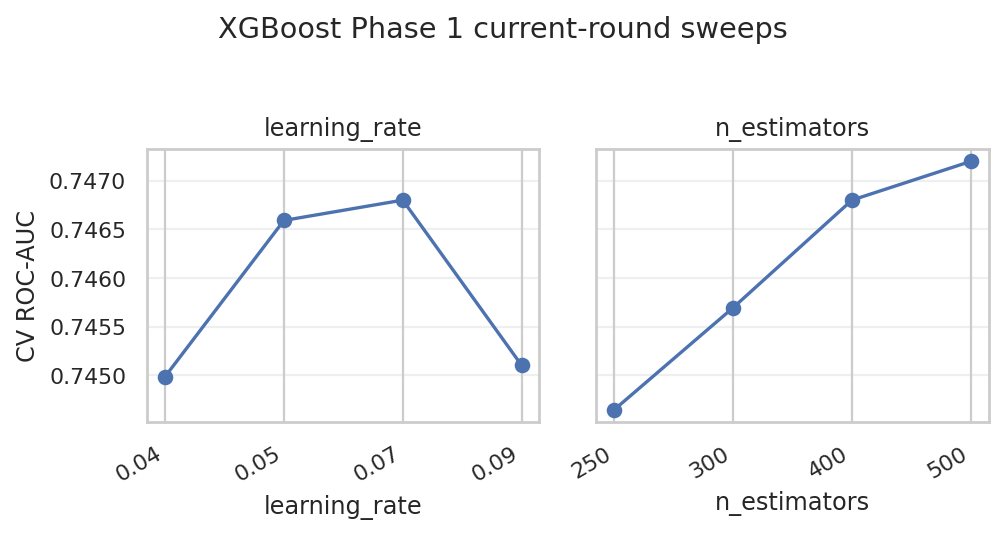

In [ ]:
from IPython.display import Image as NotebookImage

available_phase1_results = {}
for model_name, variable_name in [('LR', 'lr_p1_results'), ('RF', 'rf_p1_results'), ('XGB', 'xgb_p1_results')]:
    results_df = None
    expected_anchor = str(phase1_anchor_params[model_name])
    expected_sweeps = set(phase1_sweep_spaces[model_name])

    if phase1_csv_paths[model_name].exists():
        results_df = pd.read_csv(phase1_csv_paths[model_name])
    elif variable_name in globals():
        candidate_df = globals()[variable_name]
        if isinstance(candidate_df, pd.DataFrame) and {'anchor_params', 'sweep_param'}.issubset(candidate_df.columns):
            observed_anchor_series = candidate_df['anchor_params'].dropna()
            observed_anchor = str(observed_anchor_series.iloc[0]) if not observed_anchor_series.empty else None
            observed_sweeps = set(candidate_df['sweep_param'].dropna().unique())
            if observed_anchor == expected_anchor and expected_sweeps.issubset(observed_sweeps):
                results_df = candidate_df
        else:
            results_df = candidate_df

    if results_df is not None:
        available_phase1_results[model_name] = results_df


def active_param_specs(sweep_space):
    return [
        (param_name, param_name, candidates)
        for param_name, candidates in sweep_space.items()
    ]


if 'LR' in available_phase1_results:
    save_lr_curve(available_phase1_results['LR'], phase1_plot_paths['lr_curve'], 'Logistic Regression Phase 1')

rf_param_specs = active_param_specs(phase1_sweep_spaces['RF'])
if 'RF' in available_phase1_results and rf_param_specs:
    save_sensitivity_grid(
        available_phase1_results['RF'],
        rf_param_specs,
        phase1_plot_paths['rf_sensitivity'],
        'Random Forest Phase 1 current-round sweeps',
        (max(4.8, 3.2 * len(rf_param_specs)), 3.2),
    )

xgb_param_specs = active_param_specs(phase1_sweep_spaces['XGB'])
if 'XGB' in available_phase1_results and xgb_param_specs:
    save_sensitivity_grid(
        available_phase1_results['XGB'],
        xgb_param_specs,
        phase1_plot_paths['xgb_sensitivity'],
        'XGBoost Phase 1 current-round sweeps',
        (max(4.8, 3.2 * len(xgb_param_specs)), 3.2),
    )

for artifact_name in ['lr_curve', 'rf_sensitivity', 'xgb_sensitivity']:
    artifact_path = phase1_plot_paths[artifact_name]
    if artifact_path.exists():
        display(NotebookImage(filename=str(artifact_path)))

## Phase 2

In [5]:
lr_p2_grid = {
    'C': [0.03, 0.1, 0.3, 1.0],
}

rf_p2_dist = {
    'n_estimators': [500, 700, 900, 1100],
    'max_depth': [16, 20, 28, None],
    'min_samples_leaf': [4, 6, 8, 12],
    'max_features': [0.01, 0.02, 0.04, 0.06],
}

xgb_p2_dist = {
    'learning_rate': [0.04, 0.05, 0.07, 0.09],
    'max_depth': [4, 5, 6],
    'n_estimators': [300, 400, 500, 650],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
}

phase2_output_paths = {
    'lr_csv': results_dir / 'hpsearch_lr_p2.csv',
    'rf_csv': results_dir / 'hpsearch_rf_p2.csv',
    'xgb_csv': results_dir / 'hpsearch_xgb_p2.csv',
    'best_params': results_dir / 'best_params.csv',
    'main_clean': results_dir / 'main_clean.csv',
}

In [6]:
def build_phase2_searches():
    return {
        'LR': GridSearchCV(
            build_model_pipeline(LogisticRegression(solver='lbfgs', max_iter=1000)),
            param_grid=prefix_model_params(lr_p2_grid),
            cv=cv,
            scoring='roc_auc',
            n_jobs=SEARCH_N_JOBS,
            pre_dispatch=SEARCH_PRE_DISPATCH,
            return_train_score=True,
            verbose=SEARCH_VERBOSE,
        ),
        'RF': RandomizedSearchCV(
            build_model_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=MODEL_FIT_N_JOBS)),
            param_distributions=prefix_model_params(rf_p2_dist),
            n_iter=50,
            cv=cv,
            scoring='roc_auc',
            n_jobs=SEARCH_N_JOBS,
            pre_dispatch=SEARCH_PRE_DISPATCH,
            return_train_score=True,
            random_state=RANDOM_STATE,
            verbose=SEARCH_VERBOSE,
        ),
        'XGB': RandomizedSearchCV(
            build_model_pipeline(
                XGBClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=MODEL_FIT_N_JOBS,
                    verbosity=0,
                    eval_metric='logloss',
                )
            ),
            param_distributions=prefix_model_params(xgb_p2_dist),
            n_iter=50,
            cv=cv,
            scoring='roc_auc',
            n_jobs=SEARCH_N_JOBS,
            pre_dispatch=SEARCH_PRE_DISPATCH,
            return_train_score=True,
            random_state=RANDOM_STATE,
            verbose=SEARCH_VERBOSE,
        ),
    }


def phase2_combination_count(param_space):
    total = 1
    for candidates in param_space.values():
        total *= len(candidates)
    return total


phase2_searches = build_phase2_searches()

In [7]:
def phase2_normalize_param_value(value):
    if pd.isna(value):
        return None
    if isinstance(value, str):
        stripped = value.strip()
        if stripped.lower() == 'none':
            return None
        try:
            numeric = float(stripped)
            return int(numeric) if numeric.is_integer() else numeric
        except ValueError:
            return stripped
    if isinstance(value, (np.integer, int)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return int(value) if float(value).is_integer() else float(value)
    return value


def extract_phase2_params(best_row):
    params = {}
    for column, value in best_row.items():
        if not column.startswith('param_') or pd.isna(value):
            continue
        params[column.replace('param_', '')] = phase2_normalize_param_value(value)
    return params


def run_or_load_phase2_search(model_name, search, X_raw, y_target, csv_path, rerun=False):
    if csv_path.exists() and not rerun:
        return pd.read_csv(csv_path)

    if not rerun:
        return None

    print(f'=== {model_name} Phase 2 ===')
    print(f'output_csv={csv_path.name}')
    start = time.perf_counter()
    search.fit(X_raw, y_target)
    elapsed = time.perf_counter() - start

    results_df = normalize_cv_results(pd.DataFrame(search.cv_results_))
    results_df['model'] = model_name
    results_df.to_csv(csv_path, index=False)
    print(f'completed in {elapsed:.1f}s')
    return results_df


phase2_results = {}

for model_name, output_key in [('LR', 'lr_csv'), ('RF', 'rf_csv'), ('XGB', 'xgb_csv')]:
    results_df = run_or_load_phase2_search(
        model_name,
        phase2_searches[model_name],
        X_train_raw,
        y_train,
        phase2_output_paths[output_key],
        rerun=PHASE2_RERUN,
    )
    if results_df is not None:
        phase2_results[model_name] = results_df

completed_phase2_rows = []
for model_name, results_df in phase2_results.items():
    best_row = best_trial(results_df)
    completed_phase2_rows.append({
        'model': model_name,
        'best_params': str(extract_phase2_params(best_row)),
        'cv_auc_mean': best_row['mean_test_score'],
        'cv_auc_std': best_row['std_test_score'],
        'train_auc_mean': best_row.get('mean_train_score', np.nan),
        'source_csv': phase2_output_paths[f'{model_name.lower()}_csv'].name,
    })

if completed_phase2_rows:
    phase2_best_params = pd.DataFrame(completed_phase2_rows).sort_values('model').reset_index(drop=True)
    phase2_best_params.to_csv(phase2_output_paths['best_params'], index=False)
    display(phase2_best_params)
else:
    print('Phase 2 searches have not been launched yet. Set PHASE2_RERUN=True and rerun this cell to fit the searches and write outputs.')

,model,best_params,cv_auc_mean,cv_auc_std,train_auc_mean,source_csv
0,LR,{'C': 0.1},0.748406,0.004346,0.751424,hpsearch_lr_p2.csv
1,RF,"{'n_estimators': 1100, 'min_samples_leaf': 6, ...",0.730374,0.004750,0.999769,hpsearch_rf_p2.csv
2,XGB,"{'subsample': 0.8, 'n_estimators': 650, 'max_d...",0.749124,0.005075,0.828141,hpsearch_xgb_p2.csv


In [17]:
phase2_round2_output_paths = {
    'rf_csv': results_dir / 'hpsearch_rf_p2_round2.csv',
    'xgb_csv': results_dir / 'hpsearch_xgb_p2_round2.csv',
    'best_params': results_dir / 'best_params_round2.csv',
}

rf_p2_round2_anchor = {
    'n_estimators': 1100,
    'max_depth': 28,
    'min_samples_leaf': 6,
    'max_features': 0.04,
}
rf_p2_round2_confirmed_space = {
    'max_features': [0.04],
}
rf_p2_round2_sweeps = {
    'n_estimators': [700, 900, 1100],
    'max_depth': [20, 28, None],
    'min_samples_leaf': [6, 8, 12],
    'min_samples_split': [12, 24, 48],
    'ccp_alpha': [0.0, 1e-5, 3e-5, 1e-4],
    'max_samples': [0.6, 0.8, None],
}
rf_p2_round2_dist = {
    **rf_p2_round2_confirmed_space,
    **rf_p2_round2_sweeps,
}

xgb_p2_round2_anchor = {
    'learning_rate': 0.05,
    'max_depth': 4,
    'n_estimators': 650,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
}
xgb_p2_round2_confirmed_space = {
    'subsample': [0.8],
}
xgb_p2_round2_sweeps = {
    'learning_rate': [0.04, 0.05, 0.06],
    'max_depth': [3, 4, 5],
    'n_estimators': [500, 650, 800, 950],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0.0, 0.05, 0.1],
    'reg_lambda': [1.0, 2.0, 4.0],
    'gamma': [0.0, 0.1, 0.3],
}
xgb_p2_round2_dist = {
    **xgb_p2_round2_confirmed_space,
    **xgb_p2_round2_sweeps,
}

In [18]:
def build_phase2_round2_searches():
    return {
        'RF': RandomizedSearchCV(
            build_model_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=MODEL_FIT_N_JOBS)),
            param_distributions=prefix_model_params(rf_p2_round2_dist),
            n_iter=60,
            cv=cv,
            scoring='roc_auc',
            n_jobs=SEARCH_N_JOBS,
            pre_dispatch=SEARCH_PRE_DISPATCH,
            return_train_score=True,
            random_state=RANDOM_STATE,
            verbose=SEARCH_VERBOSE,
        ),
        'XGB': RandomizedSearchCV(
            build_model_pipeline(
                XGBClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=MODEL_FIT_N_JOBS,
                    verbosity=0,
                    eval_metric='logloss',
                )
            ),
            param_distributions=prefix_model_params(xgb_p2_round2_dist),
            n_iter=150,
            cv=cv,
            scoring='roc_auc',
            n_jobs=SEARCH_N_JOBS,
            pre_dispatch=SEARCH_PRE_DISPATCH,
            return_train_score=True,
            random_state=RANDOM_STATE,
            verbose=SEARCH_VERBOSE,
        ),
    }

phase2_round2_searches = build_phase2_round2_searches()

In [19]:
PHASE2_ROUND2_RERUN = False

phase2_round2_results = {}

for model_name, output_key in [('RF', 'rf_csv'), ('XGB', 'xgb_csv')]:
    results_df = run_or_load_phase2_search(
        model_name,
        phase2_round2_searches[model_name],
        X_train_raw,
        y_train,
        phase2_round2_output_paths[output_key],
        rerun=PHASE2_ROUND2_RERUN,
    )
    if results_df is not None:
        phase2_round2_results[model_name] = results_df

phase2_round2_best_rows = []
for model_name, results_df in phase2_round2_results.items():
    best_row = best_trial(results_df)
    phase2_round2_best_rows.append({
        'model': model_name,
        'best_params': str(extract_phase2_params(best_row)),
        'cv_auc_mean': best_row['mean_test_score'],
        'cv_auc_std': best_row['std_test_score'],
        'train_auc_mean': best_row.get('mean_train_score', np.nan),
        'source_csv': phase2_round2_output_paths[f'{model_name.lower()}_csv'].name,
    })

if phase2_round2_best_rows:
    phase2_round2_best_params = pd.DataFrame(phase2_round2_best_rows).sort_values('model').reset_index(drop=True)
    phase2_round2_best_params.to_csv(phase2_round2_output_paths['best_params'], index=False)
    display(phase2_round2_best_params)
else:
    print('Phase 2 round 2 searches have not been launched yet.')

,model,best_params,cv_auc_mean,cv_auc_std,train_auc_mean,source_csv
0,RF,"{'n_estimators': 1100, 'min_samples_split': 12...",0.730253,0.004770,0.998675,hpsearch_rf_p2_round2.csv
1,XGB,"{'subsample': 0.8, 'reg_lambda': 4, 'reg_alpha...",0.750726,0.005532,0.807241,hpsearch_xgb_p2_round2.csv


In [8]:
phase2_round3_output_paths = {
    'xgb_csv': results_dir / 'hpsearch_xgb_p2_round3.csv',
    'best_params': results_dir / 'best_params_round3.csv',
}

xgb_p2_round3_anchor = {
    'learning_rate': 0.06,
    'max_depth': 3,
    'n_estimators': 950,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'min_child_weight': 1,
    'reg_alpha': 0.0,
    'reg_lambda': 4.0,
    'gamma': 0.1,
}
xgb_p2_round3_confirmed_space = {
    'subsample': [0.8],
    'max_depth': [3, 4],
}
xgb_p2_round3_sweeps = {
    'learning_rate': [0.05, 0.06, 0.07],
    'n_estimators': [800, 950, 1100],
    'colsample_bytree': [0.65, 0.7, 0.75],
    'min_child_weight': [1, 2, 3],
    'reg_alpha': [0.0, 0.05],
    'reg_lambda': [4.0, 6.0, 8.0],
    'gamma': [0.1, 0.2, 0.3],
}
xgb_p2_round3_dist = {
    **xgb_p2_round3_confirmed_space,
    **xgb_p2_round3_sweeps,
}

In [9]:
def build_phase2_round3_searches():
    return {
        'XGB': RandomizedSearchCV(
            build_model_pipeline(
                XGBClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=MODEL_FIT_N_JOBS,
                    verbosity=0,
                    eval_metric='logloss',
                )
            ),
            param_distributions=prefix_model_params(xgb_p2_round3_dist),
            n_iter=90,
            cv=cv,
            scoring='roc_auc',
            n_jobs=SEARCH_N_JOBS,
            pre_dispatch=SEARCH_PRE_DISPATCH,
            return_train_score=True,
            random_state=RANDOM_STATE,
            verbose=SEARCH_VERBOSE,
        ),
    }

phase2_round3_searches = build_phase2_round3_searches()

In [12]:
PHASE2_ROUND3_RERUN = False

phase2_round3_results = {}

results_df = run_or_load_phase2_search(
    'XGB',
    phase2_round3_searches['XGB'],
    X_train_raw,
    y_train,
    phase2_round3_output_paths['xgb_csv'],
    rerun=PHASE2_ROUND3_RERUN,
)
if results_df is not None:
    phase2_round3_results['XGB'] = results_df

if phase2_round3_results:
    best_row = best_trial(phase2_round3_results['XGB'])
    phase2_round3_best_params = pd.DataFrame([
        {
            'model': 'XGB',
            'best_params': str(extract_phase2_params(best_row)),
            'cv_auc_mean': best_row['mean_test_score'],
            'cv_auc_std': best_row['std_test_score'],
            'train_auc_mean': best_row.get('mean_train_score', np.nan),
            'source_csv': phase2_round3_output_paths['xgb_csv'].name,
        }
    ])
    phase2_round3_best_params.to_csv(phase2_round3_output_paths['best_params'], index=False)
    display(phase2_round3_best_params)
else:
    print('XGB Phase 2 round 3 search has not been launched yet.')

,model,best_params,cv_auc_mean,cv_auc_std,train_auc_mean,source_csv
0,XGB,"{'subsample': 0.8, 'reg_lambda': 8, 'reg_alpha...",0.751567,0.005119,0.819406,hpsearch_xgb_p2_round3.csv


In [13]:
phase2_round4_output_paths = {
    'xgb_csv': results_dir / 'hpsearch_xgb_p2_round4.csv',
    'best_params': results_dir / 'best_params_round4.csv',
}

xgb_p2_round4_anchor = {
    'learning_rate': 0.07,
    'max_depth': 3,
    'n_estimators': 1100,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'min_child_weight': 2,
    'reg_alpha': 0.05,
    'reg_lambda': 8.0,
    'gamma': 0.2,
}
xgb_p2_round4_confirmed_space = {
    'subsample': [0.8],
}
xgb_p2_round4_sweeps = {
    'max_depth': [2, 3],
    'learning_rate': [0.06, 0.07, 0.08],
    'n_estimators': [1100, 1250, 1400],
    'colsample_bytree': [0.7, 0.75],
    'min_child_weight': [2, 3],
    'reg_alpha': [0.05, 0.1],
    'reg_lambda': [8.0, 10.0, 12.0],
    'gamma': [0.2, 0.3],
}
xgb_p2_round4_dist = {
    **xgb_p2_round4_confirmed_space,
    **xgb_p2_round4_sweeps,
}

In [14]:
def build_phase2_round4_searches():
    return {
        'XGB': RandomizedSearchCV(
            build_model_pipeline(
                XGBClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=MODEL_FIT_N_JOBS,
                    verbosity=0,
                    eval_metric='logloss',
                )
            ),
            param_distributions=prefix_model_params(xgb_p2_round4_dist),
            n_iter=120,
            cv=cv,
            scoring='roc_auc',
            n_jobs=SEARCH_N_JOBS,
            pre_dispatch=SEARCH_PRE_DISPATCH,
            return_train_score=True,
            random_state=RANDOM_STATE,
            verbose=SEARCH_VERBOSE,
        ),
    }

phase2_round4_searches = build_phase2_round4_searches()

In [16]:
PHASE2_ROUND4_RERUN = False

phase2_round4_results = {}

results_df = run_or_load_phase2_search(
    'XGB',
    phase2_round4_searches['XGB'],
    X_train_raw,
    y_train,
    phase2_round4_output_paths['xgb_csv'],
    rerun=PHASE2_ROUND4_RERUN,
)
if results_df is not None:
    phase2_round4_results['XGB'] = results_df

if phase2_round4_results:
    best_row = best_trial(phase2_round4_results['XGB'])
    phase2_round4_best_params = pd.DataFrame([
        {
            'model': 'XGB',
            'best_params': str(extract_phase2_params(best_row)),
            'cv_auc_mean': best_row['mean_test_score'],
            'cv_auc_std': best_row['std_test_score'],
            'train_auc_mean': best_row.get('mean_train_score', np.nan),
            'source_csv': phase2_round4_output_paths['xgb_csv'].name,
        }
    ])
    phase2_round4_best_params.to_csv(phase2_round4_output_paths['best_params'], index=False)
    display(phase2_round4_best_params)
else:
    print('XGB Phase 2 round 4 search has not been launched yet.')

,model,best_params,cv_auc_mean,cv_auc_std,train_auc_mean,source_csv
0,XGB,"{'subsample': 0.8, 'reg_lambda': 8, 'reg_alpha...",0.752173,0.004552,0.824652,hpsearch_xgb_p2_round4.csv
